## Supplementary experiments
This version supplements the code file “Champion-analysis” by adding a set of standard BO hyperparameters that need to be trained and tested, then compared against existing stored results. All settings remain consistent with the previous ones to ensure a fair comparison.


In [ ]:
import os
import random
import numpy as np
import tensorflow as tf
import time
import shutil
import pathlib
import itertools
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from tensorflow import keras
from keras import models, optimizers, metrics, layers, regularizers, losses
from keras.models import Sequential
from keras.optimizers import SGD, RMSprop, Adam, Adagrad
import json

def set_reproducibility(seed=88):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.config.experimental.enable_op_determinism()
    print(f"✅ 全局随机种子已设置为: {seed}，并已启用TensorFlow确定性操作。")

SEED_VALUE = 88 
set_reproducibility(SEED_VALUE)

2026-03-22 06:07:55.123948: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774159675.297875      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774159675.350476      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

✅ 全局随机种子已设置为: 88，并已启用TensorFlow确定性操作。


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow import keras
from keras import layers
import matplotlib.image as img

!pip install split-folders -q
import splitfolders
input_dir="/kaggle/input/augmented-alzheimer-data/augmented_data"
output_dir="./output"
splitfolders.ratio(
    input_dir, 
    output=output_dir, 
    seed=1345, 
    ratio=(.70, 0.15,0.15),
    group_prefix=None 
) 
print("Dataset split completed!")

# #验证输出路径文件夹文件数量
# def count_files(directory):
#     for split in ['train', 'val', 'test']:
#         split_path = os.path.join(directory, split)
#         print(f"\n{split.upper()} set:")
#         for class_name in os.listdir(split_path):
#             class_path = os.path.join(split_path, class_name)
#             num_files = len(os.listdir(class_path))
#             print(f"  {class_name}: {num_files} images")

# count_files("./output")

AUTOTUNE = tf.data.AUTOTUNE
IMG_HEIGHT = 224
IMG_WIDTH = 224 
batch_size=32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
"./output/train",
seed=123,
label_mode='int',
image_size=(IMG_HEIGHT, IMG_WIDTH),
batch_size=batch_size,
shuffle=True
).prefetch(buffer_size=AUTOTUNE)
# 默认情况下label_mode='int'后续匹配sparse_categorical_crossentropy	需设置from_logits=True/False


test_ds = tf.keras.preprocessing.image_dataset_from_directory(
"./output/test",
label_mode='int',
seed=123,
image_size=(IMG_HEIGHT, IMG_WIDTH),
batch_size=batch_size,
shuffle=False  
).prefetch(buffer_size=AUTOTUNE)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
"./output/val",
label_mode='int',
seed=123,
image_size=(IMG_HEIGHT, IMG_WIDTH),
batch_size=batch_size,
shuffle=False
).prefetch(buffer_size=AUTOTUNE)

Copying files: 12800 files [01:13, 173.19 files/s]


Dataset split completed!
Found 8960 files belonging to 4 classes.


I0000 00:00:1774159770.425191      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774159770.428034      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1920 files belonging to 4 classes.
Found 1920 files belonging to 4 classes.


In [ ]:
import os, random, time, gc, json
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
import tensorflow as tf, tensorflow_probability as tfp
from tensorflow import keras
from keras import layers, regularizers
import scipy.stats as stats
tfd = tfp.distributions
sns.set_style('whitegrid')
tf.keras.backend.set_floatx('float64')

#-----------------------------模型架构搭建：顺序模型------------------------------
def build_pretrained_model(hparams):
    
    base_model = tf.keras.applications.EfficientNetB0(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
        include_top=False,
        weights='imagenet'
    )
    
    base_model.trainable = False
    
    fine_tune_at_block = 'block5a_expand_conv'
    
    set_trainable = False
    for layer in base_model.layers:
        if layer.name == fine_tune_at_block:
            set_trainable = True
        if set_trainable:
            layer.trainable = True
        else:
            layer.trainable = False

    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
    
    dense_units = int(hparams.get('dense_units', 128))
    dropout_rate = hparams.get('dropout_rate', 0.5)
    l2_reg = hparams.get('l2_reg', 0.001)
    lr = hparams.get('lr', 0.0001)
    optimizer_choice = int(hparams.get('optimizer_choice', 0))
    momentum = hparams.get('momentum', 0.9)
    
    model = tf.keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(), 
        layers.Dense(dense_units, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)), 
        layers.Dropout(dropout_rate),
        layers.Dense(4, activation='softmax') 
    ])

    if optimizer_choice == 0:
        print("--- 使用 Adam 优化器 ---")
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_choice == 1:
        print(f"--- 使用 SGD 优化器 (momentum={momentum:.3f}) ---")
        optimizer = tf.keras.optimizers.SGD(learning_rate=lr, momentum=momentum)
    elif optimizer_choice == 2:
        print("--- 使用 RMSprop 优化器 ---")
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=lr)
    else: # optimizer_choice == 3
        print("--- 使用 Adagrad 优化器 ---")
        optimizer = tf.keras.optimizers.Adagrad(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
   
    return model


class TrainingCallback(keras.callbacks.Callback):
    def __init__(self, epochs):
        super().__init__()
        self.epochs = epochs
    def on_train_begin(self, logs=None):
        header = "{0:^8s}{1:^11s}{2:^11s}{3:^12s}{4:^12s}{5:^12s}".format('Epoch', 'Loss', 'Acc', 'Val_Loss', 'Val_Acc', 'Duration')
        print(header)
    def on_epoch_begin(self, epoch, logs=None): 
        self.ep_start = time.time()
    def on_epoch_end(self, epoch, logs=None):
        duration = time.time() - self.ep_start
        acc = logs.get('accuracy', 0); val_acc = logs.get('val_accuracy', 0)
        loss = logs.get('loss', 0); val_loss = logs.get('val_loss', 0)
        msg = f'{str(epoch + 1):^3s}/{str(self.epochs):4s} {loss:^10.3f}{acc * 100:^11.3f}{val_loss:^12.5f}{val_acc * 100:^12.3f}{duration:^12.2f}'
        print(msg)

In [ ]:
# ===================================================================
#从三组优化探索的日志结果中提取出val_acc最高时的对应超参数配置
# ===================================================================
import json
import pandas as pd
import matplotlib.pyplot as plt
import gc
import time
import numpy as np

def get_champion_hyperparameters(log_file_random, log_file_bo, log_file_standard, init_points_bo=10):
    """
    从三个日志文件中加载结果，并找出四组冠军超参数。
    """
    
    def load_full_logs(file_path):
        """对于RS、BO、standardBO 的25次超参数探索日志，加载其中完整的日志条目。"""
        try:
            with open(file_path, 'r') as f:
                return [json.loads(line) for line in f if line.strip()]
        except FileNotFoundError:
            print(f"❌ 错误: 日志文件 '{file_path}' 未找到。")
            return None

    logs_random = load_full_logs(log_file_random)
    logs_bo = load_full_logs(log_file_bo)
    logs_standard = load_full_logs(log_file_standard)

    if not logs_random or not logs_bo or not logs_standard:
        print("缺少必要的日志文件，无法继续。")
        return None

    # 筛选RS的参数冠军
    best_random_entry = max(logs_random, key=lambda log: log['accuracy'])
    random_champion_params = best_random_entry['params']
    
    # 同上但BO,只筛选BO搜索时期的最优超参
    bo_phase_logs = logs_bo[init_points_bo:]
    if bo_phase_logs:
        best_bo_entry = max(bo_phase_logs, key=lambda log: log['accuracy'])
        bo_champion_params = best_bo_entry['params']
    else:
        print("警告: MCMC BO优化阶段没有数据点，将跳过此冠军。")
        bo_champion_params = {}

    # 同上，但Standard BO
    standard_phase_logs = logs_standard[init_points_bo:]
    if standard_phase_logs:
        best_standard_entry = max(standard_phase_logs, key=lambda log: log['accuracy'])
        standard_champion_params = best_standard_entry['params']
    else:
        print("警告: Standard BO优化阶段没有数据点，将跳过此冠军。")
        standard_champion_params = {}

    # 定义人类基准冠军参数
    manual_baseline_params = {
        'lr': 0.00005,
        'dense_units': 256.0,
        'dropout_rate': 0.5,
        'l2_reg': 0.001,
        'optimizer_choice': 0,
        'momentum': 0.9
    }
    
    champions = {
        "Human Baseline": manual_baseline_params,
        "Random Search Champion": random_champion_params,
        "BO Champion": bo_champion_params,
        "Standard BO Champion": standard_champion_params
    }
    
    # 确保某几个参数符合对应dtype
    final_champions = {}
    for name, params in champions.items():
        if params:
            if 'dense_units' in params:
                params['dense_units'] = int(params['dense_units'])
            if 'optimizer_choice' in params:
                params['optimizer_choice'] = int(params['optimizer_choice'])
            final_champions[name] = params

    print("四组超参数配置详情：")
    for name, params in final_champions.items():
        print(f"\n🏆 {name}:")
        for key, value in params.items():
            if isinstance(value, int):
                print(f"   - {key}: {value}")
            else:
                print(f"   - {key}: {float(value):.6f}")
            
    return final_champions

# ===================================================================
# 步骤 2: 定义最终的训练与评估函数（与原版相同）
# ===================================================================
def train_and_evaluate_champion(hparams, train_ds, val_ds, test_ds):
    tf.keras.backend.clear_session(); gc.collect()
    
    if 'optimizer_choice' in hparams:
        hparams['optimizer_choice'] = int(hparams['optimizer_choice'])
        
    model = build_pretrained_model(hparams)
    
    MAX_EPOCHS = 100
    PATIENCE = 10

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', 
        patience=PATIENCE, 
        min_delta=0.001, 
        restore_best_weights=True, 
        verbose=1)
    
    lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
    
    logging_callback = TrainingCallback(epochs=MAX_EPOCHS)
    
    start_time = time.time()
    history = model.fit(
        train_ds, 
        validation_data=val_ds, 
        epochs=MAX_EPOCHS, 
        callbacks=[logging_callback, early_stopping, lr_scheduler], 
        verbose=0)
    training_duration = time.time() - start_time
    
    print("\n--- 正在进行最终评估 ---")
    val_loss, val_acc = model.evaluate(val_ds, verbose=0)
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    best_epoch = early_stopping.best_epoch + 1 if early_stopping.best_epoch >= 0 else len(history.history['loss'])

    return {
        "val_accuracy": val_acc,
        "test_accuracy": test_acc,
        "best_epoch": best_epoch,
        "history": history.history,
        "training_time": training_duration
    }
    

四组超参数配置详情：

🏆 Human Baseline:
   - lr: 0.000050
   - dense_units: 256
   - dropout_rate: 0.500000
   - l2_reg: 0.001000
   - optimizer_choice: 0
   - momentum: 0.900000

🏆 Random Search Champion:
   - lr: 0.000327
   - dense_units: 291
   - dropout_rate: 0.464171
   - l2_reg: 0.004482
   - optimizer_choice: 2
   - momentum: 0.950002

🏆 BO Champion:
   - lr: 0.000103
   - dense_units: 398
   - dropout_rate: 0.289009
   - l2_reg: 0.000877
   - optimizer_choice: 2
   - momentum: 0.927550

🏆 Standard BO Champion:
   - lr: 0.000147
   - dense_units: 429
   - dropout_rate: 0.518592
   - l2_reg: 0.003566
   - optimizer_choice: 0
   - momentum: 0.906071

 发现旧的训练历史文件: /kaggle/input/datasets/earthajasmine/history-data/champion_training_histories.json
✅ 已加载 3 组旧的训练历史
 发现旧的结果文件: /kaggle/input/datasets/earthajasmine/history-data/champion_showdown_final_results.csv
✅ 已加载 3 组旧的结果数据

🥊 开始补充实验训练: Standard BO Champion
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
--- 使用 Adam 优化器 ---
 Epoch     Loss

E0000 00:00:1774159793.828168      20 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1774159796.238101      75 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1 /100    2.489     66.629     1.88417      76.146      180.72   
 2 /100    1.527     79.062     1.27443      79.844      159.67   
 3 /100    1.048     84.275     0.85174      86.979      159.74   
 4 /100    0.723     89.051     0.64019      89.010      159.65   
 5 /100    0.495     93.013     0.42961      93.594      159.60   
 6 /100    0.359     94.810     0.31769      95.469      159.74   
 7 /100    0.239     97.087     0.33017      94.323      159.68   
 8 /100    0.192     97.310     0.20609      96.823      159.72   
 9 /100    0.135     98.315     0.16785      97.240      159.71   
10 /100    0.113     98.382     0.23164      94.427      159.70   
11 /100    0.107     98.248     0.15432      96.615      159.69   
12 /100    0.090     98.348     0.13519      96.719      159.50   
13 /100    0.073     98.571     0.09111      98.177      159.50   
14 /100    0.060     98.862     0.12066      96.927      159.44   
15 /100    0.047     99.141     0.10982      97.344      159.5

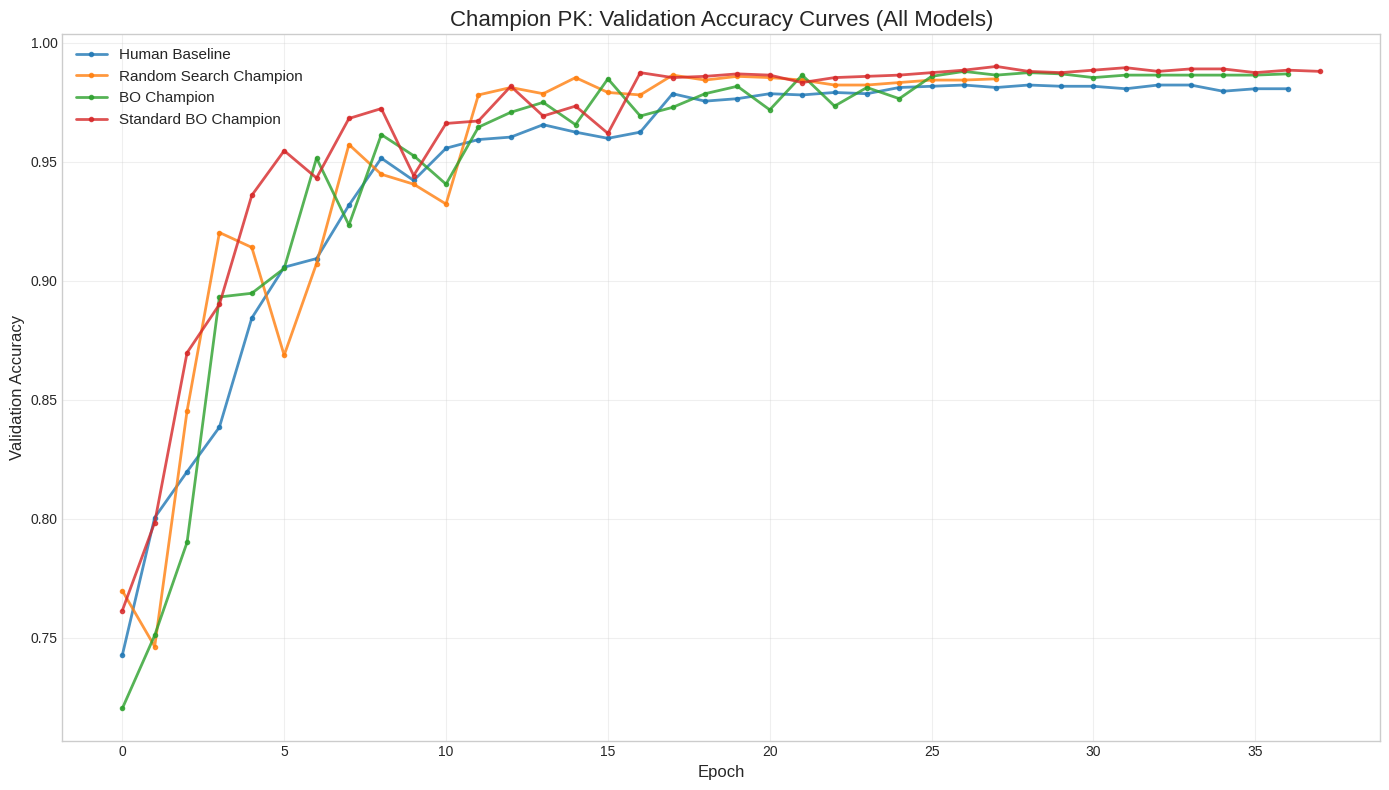

In [ ]:
# ===================================================================
# main
# ===================================================================
# 定义日志文件路径
log_file_random = "/kaggle/input/datasets/evelyn168/random-data-25/second_resumed_random_search_25.json" 
log_file_bo="/kaggle/input/datasets/evelyn168/bo-data-30/second_continued_EI_MCMC_BO_log30.json" 
log_file_standard="/kaggle/input/datasets/earthajasmine/standard-bover5-25/standard_bo_map_v5_25.json" 

# 获取所有冠军参数
champions_to_train = get_champion_hyperparameters(
    log_file_random=log_file_random,
    log_file_bo=log_file_bo,
    log_file_standard=log_file_standard,
    init_points_bo=10
)

# 尝试加载之前保存的结果,并加入最新的standar BO的训练历史记录
final_results = {}
training_histories = {}
# 输入文件（旧结果）
old_results_path = "/kaggle/input/datasets/earthajasmine/history-data/champion_showdown_final_results.csv"
old_history_path = "/kaggle/input/datasets/earthajasmine/history-data/champion_training_histories.json"
# 输出文件（包含Standard BO的新结果）
new_results_path = "champion_showdown_update.csv"
new_history_path = "champion_training_histories_update.json"

# 加载旧的训练历史.json文件
if os.path.exists(old_history_path):
    print(f"\n 发现旧的训练历史文件: {old_history_path}")
    with open(old_history_path, 'r') as f:
        training_histories = json.load(f)
    print(f"✅ 已加载 {len(training_histories)} 组旧的训练历史")
else:
    print(f"未找到旧的训练历史文件 '{old_history_path}'，将从空开始。")

# 加载旧的结果数据.csv文件
if os.path.exists(old_results_path):
    print(f" 发现旧的结果文件: {old_results_path}")
    old_df = pd.read_csv(old_results_path)
    for _, row in old_df.iterrows():
        final_results[row['Champion']] = {
            'val_accuracy': row['Validation Accuracy'],
            'test_accuracy': row['Test Accuracy'],
            'best_epoch': row['Converged at Epoch'],
            'training_time': 0  # 旧数据的训练时间无法恢复
        }
    print(f"✅ 已加载 {len(final_results)} 组旧的结果数据\n")
else:
    print(f" 未找到旧的结果文件 '{old_results_path}'，将从空开始。\n")

# 补充训练：只训练 Standard BO Champion
TARGET_CHAMPION = "Standard BO Champion"

if champions_to_train and TARGET_CHAMPION in champions_to_train:
    # 检查是否已经训练过
    if TARGET_CHAMPION in final_results:
        print(f"{TARGET_CHAMPION}已存在于旧结果中，将被新结果覆盖。\n")
    
    name = TARGET_CHAMPION
    params = champions_to_train[name]
    
    print(f"{'='*60}\n🥊 开始补充实验训练: {name}\n{'='*60}")
    
    
    results = train_and_evaluate_champion(params, train_ds, val_ds, test_ds)
    
    # 更新或添加新结果
    final_results[name] = results
    training_histories[name] = results['history']
    
    print(f"\n✅ 组合 {name} 训练完成!")
    print(f"   - 收敛于轮次 (Converged at Epoch): {results['best_epoch']}")
    print(f"   - 验证集准确率 (Validation Acc): {results['val_accuracy']:.4f}")
    print(f"   - 最终测试集准确率 (Test Acc): {results['test_accuracy']:.4f}")
    print(f"   - 训练耗时: {results['training_time'] / 60:.2f} 分钟")
else:
    print(f"\n❌ 未找到 '{TARGET_CHAMPION}' 的超参数配置，无法进行训练。")

# ===================================================================
# 公布合并后的结果与可视化
# ===================================================================
def format_time(seconds):
    if seconds == 0:
        return "N/A"
    hours, remainder = divmod(int(seconds), 3600)
    minutes, secs = divmod(remainder, 60)
    return f"{hours:02d}:{minutes:02d}:{secs:02d}"

if final_results:
    print(f"\n{'='*60}\n🏆 冠军对决最终结果 (包含所有模型) 🏆\n{'='*60}")
    
    results_df = pd.DataFrame({
        'Champion': list(final_results.keys()),
        'Validation Accuracy': [res['val_accuracy'] for res in final_results.values()],
        'Test Accuracy': [res['test_accuracy'] for res in final_results.values()],
        'Converged at Epoch': [res['best_epoch'] for res in final_results.values()],
        'Training Time': [format_time(res['training_time']) for res in final_results.values()]
    }).sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)

    print(results_df.to_string())
    
    # 保存合并后的结果到新的CSV文件
    results_df.to_csv(new_results_path, index=False)
    print(f"\n[INFO] ✅ 包含所有模型的最终结果已保存到: {new_results_path}")
    
    # 同时保存训练历史到新的JSON文件
    with open(new_history_path, 'w') as f:
        json.dump(training_histories, f, indent=4)
    print(f"[INFO] ✅ 包含所有模型的训练历史已保存到: {new_history_path}")

    winner = results_df.iloc[0]
    print(f"\n🎉 总冠军是: {winner['Champion']}, 最终测试集准确率为 {winner['Test Accuracy']:.4f}!")

    # 绘制包含所有模型的验证集准确率曲线
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(14, 8))
    for name, history in training_histories.items():
        plt.plot(history['val_accuracy'], label=f'{name}', lw=2, marker='o', markersize=3, alpha=0.8)

    plt.title('Champion PK: Validation Accuracy Curves (All Models)', fontsize=16)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Validation Accuracy', fontsize=12)
    plt.legend(fontsize=11, loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('championship_curves_all_models.pdf', dpi=150)
    plt.show()
else:
    print("\n未能确定冠军组合，无法开始对决。")

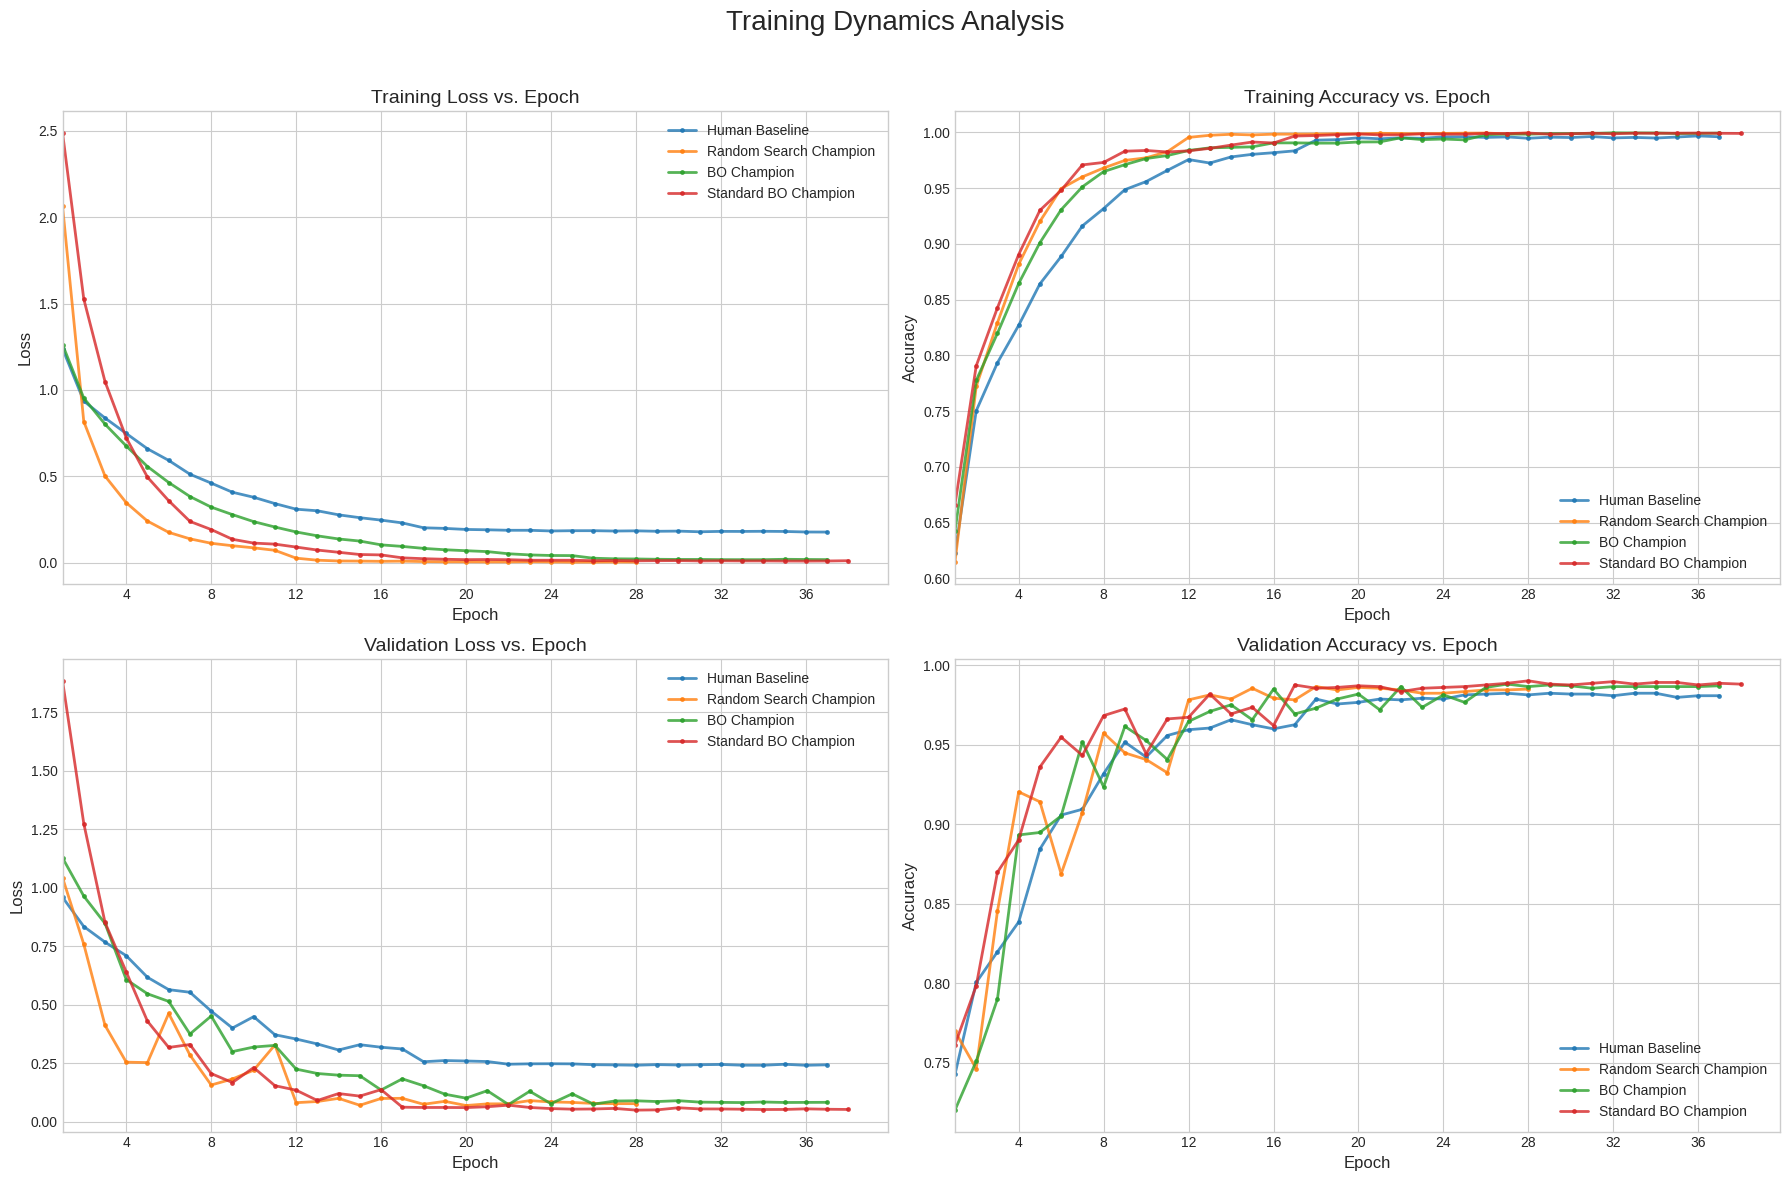

In [ ]:
if final_results:
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
    
    colors = {
        "Human Baseline": "C0", # 蓝色
        "Random Search Champion": "C1", # 橙色
        "BO Champion": "C2",   # 绿色
        "Standard BO Champion": "C3"  # 红色
    }

    # 遍历每个冠军的训练历史
    for name, history in training_histories.items():
        # 提取各个指标的历史数据
        loss_history = history['loss']
        acc_history = history['accuracy']
        val_loss_history = history['val_loss']
        val_acc_history = history['val_accuracy']
        
        # 创建从1开始的Epoch X轴
        epochs = range(1, len(loss_history) + 1)

        # 1. 左上角：训练集损失 (Training Loss)
        axes[0, 0].plot(epochs, loss_history, label=name, color=colors.get(name), lw=2, marker='.', markersize=5, alpha=0.8)
        
        # 2. 右上角：训练集准确率 (Training Accuracy)
        axes[0, 1].plot(epochs, acc_history, label=name, color=colors.get(name), lw=2, marker='.', markersize=5, alpha=0.8)
        
        # 3. 左下角：验证集损失 (Validation Loss)
        axes[1, 0].plot(epochs, val_loss_history, label=name, color=colors.get(name), lw=2, marker='.', markersize=5, alpha=0.8)
        
        # 4. 右下角：验证集准确率 (Validation Accuracy)
        axes[1, 1].plot(epochs, val_acc_history, label=name, color=colors.get(name), lw=2, marker='.', markersize=5, alpha=0.8)

    # 设置标题
    axes[0, 0].set_title('Training Loss vs. Epoch', fontsize=14)
    axes[0, 1].set_title('Training Accuracy vs. Epoch', fontsize=14)
    axes[1, 0].set_title('Validation Loss vs. Epoch', fontsize=14)
    axes[1, 1].set_title('Validation Accuracy vs. Epoch', fontsize=14)

    # 循环为每个子图设置标签、图例和网格
    for i in range(2):
        for j in range(2):
            axes[i, j].set_xlabel('Epoch', fontsize=12)
            axes[i, j].legend(fontsize=10)
            axes[i, j].grid(True)
            # 确保X轴刻度为整数
            ax = axes[i, j]
            ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
            ax.set_xlim(left=1)

    # 单独设置Y轴标签
    axes[0, 0].set_ylabel('Loss', fontsize=12)
    axes[0, 1].set_ylabel('Accuracy', fontsize=12)
    axes[1, 0].set_ylabel('Loss', fontsize=12)
    axes[1, 1].set_ylabel('Accuracy', fontsize=12)
    
    # 添加一个总标题
    fig.suptitle('Training Dynamics Analysis', fontsize=20)
    
    # 调整子图布局，防止标题和标签重叠
    fig.tight_layout(rect=[0, 0, 1, 0.96]) # rect为总标题留出空间

    # 保存并显示图像
    plt.savefig('championship_match_details_2x2.pdf')
    plt.show()

else:
    print("\n未能执行最终对决，跳过生成 2x2 曲线图。")